In [1111]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity

In [1112]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [1127]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake, num_layers_wake, hidden_sleep, num_layers_sleep, output_sleep, hidden_compressor=5):
        super(brain, self).__init__()
        
        self.network_wake = nn.RNN(input_size+output_sleep, hidden_wake, num_layers_wake, nonlinearity='relu', batch_first=True)
        self.network_sleep = nn.RNN(input_size, hidden_sleep, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.compressor = nn.RNN(input_size, hidden_compressor, 1, nonlinearity='relu', batch_first=True)
        
        self.sleep_fc = nn.Linear(hidden_sleep, output_sleep)
        self.wake_fc = nn.Linear(hidden_wake, len(tokens))
        self.compressor_fc = nn.Linear(hidden_compressor, 2)
        
        self.sleep_output = torch.zeros(1, 1, output_sleep)
        self.sleep_output.requires_grad = False

    def freeze_param(self, state='wake'):
        if state == 'sleep':
            self.network_sleep.requires_grad = True
            self.sleep_fc.requires_grad = True
            self.network_wake.requires_grad = True
            self.wake_fc.requires_grad = True
            self.compressor.requires_grad = False
            self.compressor_fc.requires_grad = False
        elif state == 'wake':
            self.network_sleep.requires_grad = False
            self.sleep_fc.requires_grad = False
            self.network_wake.requires_grad = True
            self.wake_fc.requires_grad = True
            self.compressor.requires_grad = False
            self.compressor_fc.requires_grad = False
    
        elif state == 'compressor':
            self.network_sleep.requires_grad = False
            self.sleep_fc.requires_grad = False
            self.network_wake.requires_grad = False
            self.wake_fc.requires_grad = False
            self.compressor.requires_grad = True
            self.compressor_fc.requires_grad = True
        else:
            raise ValueError('Unknown state!!!')

        
    def forward(self, x, train_compressor = False, sleep = False, hw=None, hs=None, hc=None, sleep_output=None):
        if train_compressor:
            if hc == None:
                out, hc = self.compressor(x)
            else:
                out, hc = self.compressor(x, hc)

            out = self.compressor_fc(out)

            return out, hc
            
        if sleep:
            if hs == None:
                out, hs = self.network_sleep(x)
            else:
                out, hs = self.network_sleep(x, hs)

            sleep_output = self.sleep_fc(out)


        if sleep_output != None:
            input_wake = x = torch.cat((x, nn.functional.relu(sleep_output)), dim=2)
        else:
            input_wake = x = torch.cat((x, self.sleep_output), dim=2)

        if hw == None:
            out, hw = self.network_wake(input_wake)
        else:
            out, hw = self.network_wake(input_wake, hw)

        out = self.wake_fc(out)

        if sleep:
            return out, hw, hs, sleep_output
            
        return out, hw

In [1128]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [1129]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [1130]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [1131]:
### initial training ###
total_samples = 30000
working_memory = 1
short_term_memory = 1
hidden_wake = 300
hidden_sleep = 500
num_layers_wake = 2
num_layers_sleep = 2
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4

data = get_sequence(total_samples, n_community, n_members)
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

brain_model = brain(input_size, hidden_wake, num_layers_wake, hidden_sleep, num_layers_sleep, output_sleep)
brain_model.freeze_param(state='wake')

optimizer = torch.optim.SGD(brain_model.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
torch.autograd.set_detect_anomaly(True)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = brain_model(X)
    else:
        predicted_y, hidden = brain_model(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 2.0196, accuracy: 0.1970
Iter : 2001, loss: 2.2188, accuracy: 0.2580
Iter : 3001, loss: 1.6851, accuracy: 0.3570
Iter : 4001, loss: 1.8274, accuracy: 0.5610
Iter : 5001, loss: 2.7920, accuracy: 0.6560
Iter : 6001, loss: 3.0067, accuracy: 0.7400
Iter : 7001, loss: 1.3572, accuracy: 0.7420
Iter : 8001, loss: 1.3627, accuracy: 0.7450
Iter : 9001, loss: 1.6966, accuracy: 0.7530
Iter : 10001, loss: 2.1183, accuracy: 0.7470
Iter : 11001, loss: 1.1669, accuracy: 0.7580
Iter : 12001, loss: 1.9006, accuracy: 0.7490
Iter : 13001, loss: 1.3136, accuracy: 0.7450
Iter : 14001, loss: 1.6963, accuracy: 0.7510
Iter : 15001, loss: 0.9878, accuracy: 0.7510
Iter : 16001, loss: 1.2896, accuracy: 0.7460
Iter : 17001, loss: 1.9872, accuracy: 0.7520
Iter : 18001, loss: 1.7406, accuracy: 0.7400
Iter : 19001, loss: 1.4228, accuracy: 0.7430
Iter : 20001, loss: 1.4243, accuracy: 0.7440
Iter : 21001, loss: 1.8844, accuracy: 0.7490
Iter : 22001, loss: 1.8737, accuracy: 0.7500
Iter : 23001, loss:

In [1132]:
compressor_sample = 10000

data_compressor = get_sequence(compressor_sample, n_community, n_members)
data_set_compressor = Dataset_converter(data_compressor, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# community = ''

with torch.no_grad():
    for X, _ in compressor_loader:
        if ii==0:
            id, hw = brain_model(X)
            id_current = hw
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = brain_model(X, hw=hw)
            id_current = hw
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [1133]:
dis_array = np.array(dis)
threshold = np.quantile(dis_array, .6)

mask = ((dis_array>threshold)*1)

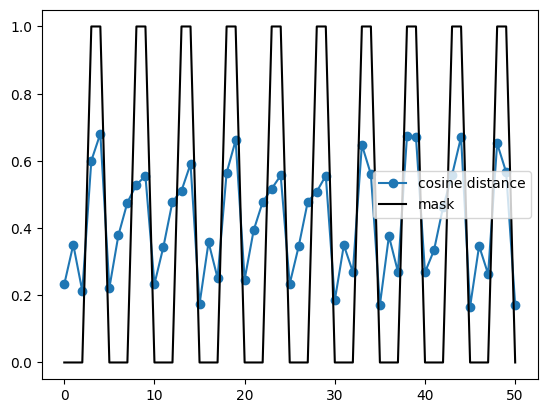

In [1134]:
span = 51
plt.plot(dis[1:span+1], '-o', label='cosine distance')
plt.plot(mask[1:span+1], c='k', label = 'mask')
plt.legend()

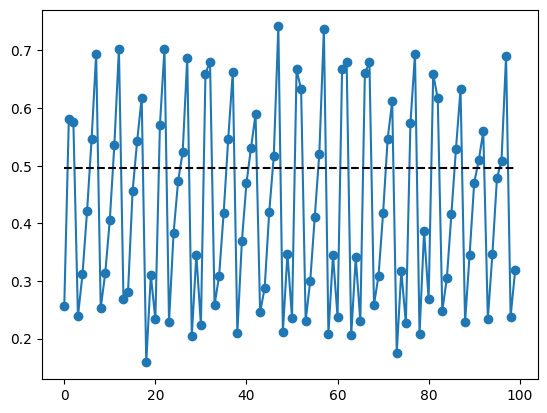

In [1135]:
span = 100
plt.plot(dis[-span:], '-o')
plt.plot(np.arange(span), [threshold]*span, '--', c='k')

In [1136]:
mask[:100]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1])

In [1137]:
data_set = Dataset_converter_compressor(data_compressor, mask)
compressor_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

brain_model.freeze_param(state='compressor')
optimizer = torch.optim.SGD(brain_model.parameters(), lr=4e-3, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in compressor_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = brain_model(X, train_compressor=True)
    else:
        predicted_y, hidden = brain_model(X, train_compressor=True, hc=mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()

        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compression.append((true_y[0],estimated_y[0],tokens[X.argmax(axis=1)]))
            
        total += 1
        if true_y == estimated_y:
            correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



Iter : 1001, loss: 0.0145, accuracy: 0.9300
Iter : 2001, loss: 0.0038, accuracy: 0.9550
Iter : 3001, loss: 0.0003, accuracy: 1.0000
Iter : 4001, loss: 0.0007, accuracy: 1.0000
Iter : 5001, loss: 0.0004, accuracy: 1.0000
Iter : 6001, loss: 0.0001, accuracy: 1.0000
Iter : 7001, loss: 0.0001, accuracy: 1.0000
Iter : 8001, loss: 0.0001, accuracy: 1.0000
Iter : 9001, loss: 0.0003, accuracy: 0.9970


In [1138]:
compressed_seq = ''
data = get_sequence(3000, n_community, n_members, train=False, random_state=rep)
data_test = Dataset_converter_compressor(data, mask)
test_loader = DataLoader(data_test, batch_size=1, shuffle=False) 

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in test_loader:      

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = brain_model(X, train_compressor=True)
        else:
            predicted_y, hidden = brain_model(X, train_compressor=True, hc=hidden)


        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compressed_seq += tokens[X.argmax(axis=1)]
            
        total += 1

In [1139]:
compressed_seq

'GDGDGCGDGEGFGDGFGFGEGCGCGFGCGCGAGCGAGDGBGEGFGBGAGFGEGDGEGCGEGCGFGBGFGFGCGFGEGCGCGFGCGDGEGEGDGEGAGEGBGFGDGDGEGAGFGBGBGFGDGAGEGBGFGAGAGAGCGCGEGEGBGBGAGDGDGAGFGCGAGEGAGEGFGFGEGDGDGBGDGDGCGBGDGCGAGDGEGAGFGAGBGDGAGBGAGDGEGAGFGAGAGBGBGBGEGAGFGCGFGEGDGDGDGCGFGEGFGFGCGFGDGCGCGFGCGCGCGBGEGDGBGAGEGBGEGDGDGEGBGAGAGEGBGEGEGDGCGDGAGCGFGAGDGFGCGCGDGBGFGBGEGAGDGBGDGCGCGBGEGCGFGBGFGAGAGBGAGBGDGAGBGFGBGBGCGDGBGBGEGAGDGCGBGFGFGBGBGCGDGFGAGAGCGBGCGFGAGFGBGCGCGDGEGEGAGBGEGFGDGEGAGCGBGDGEGAGFGCGBGEGAGEGFGFGFGBGAGCGFGEGEGBGEGDGEGDGAGCGFGEGCGAGBGEGEGBGFGEGDGEGFGAGCGCGFGCGEGCGEGEGCGAGCGFGBGBGEGEGFGDGAGDGAGBGCGBGEGFGFGCGEGAGBGEGFGEGDGDGEGCGBGDGDGEGDGEGDGFGDGEGEGCGAGBGAGFGEGFGBGDGEGFGEGFGEGFGAGBGAGBGEGDGCGDGAGBGFGCGDGAGFGAGBGBGAGEGFGDGBGDGCGEGCGAGAGBGFGDGFGCGEGCGAGDGEGFGAGDGEGCGFGCGDGDGBGAGEGEGCGEGFGFGDGDGEGBGBGEGAGEGCGAGFGEGDGFGDGCGDGFGFGCGAGFGFGBGFGEGDGCGAGBGEGAGCGAGBGBGCGEGFGFGCGBGDGDGEGAGDGBGDGBGFGFGDGBGFGBGBGEGAGFGAGBGFGAGCGAGBGCGBGBGCGCGDGAGEGDGCGFGFGEGAGAGDGDGDGDGAGEGAGDGAGBGAGBGEGEGFGDGFGAGEGBGDGAGEGAG

In [1142]:
sleep_samples = 20000
compressed_seq = ''
data_sleep = get_sequence(sleep_samples, n_community, n_members)
data_set_sleep = Dataset_converter(data_sleep, working_memory, short_term_memory)

sleep_loader = DataLoader(data_set_sleep, batch_size=1, shuffle=False)
brain_model.freeze_param(state='sleep')

optimizer = torch.optim.SGD(brain_model.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
torch.autograd.set_detect_anomaly(True)
for X, y in sleep_loader:

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = brain_model(X[0], train_compressor=True)
        else:
            predicted_y, hidden = brain_model(X[0], train_compressor=True, hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            sleep = True
        else:
            sleep = False

        # print(sleep, data_sleep[total])
        # total += 1
    ####################################################################
    optimizer.zero_grad()

    if sleep:
        compressed_seq += data_sleep[total]
        # print('slept', sleep_mem)
        if total == 0:
            predicted_y, hidden_w, hidden_s, sleep_output = brain_model(X, sleep=sleep, sleep_output=sleep_mem)
        else:
            predicted_y, hidden_w, hidden_s, sleep_output = brain_model(X, sleep=sleep, hw=mem, hs=mem_, sleep_output=sleep_mem)
    else:  
        # print('not slept', sleep_mem)
        if total == 0:
            predicted_y, hidden_w = brain_model(X, sleep_output=sleep_mem)
        else:
            predicted_y, hidden_w = brain_model(X, hw=mem, sleep_output=sleep_mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden_w.clone()
        mem_=hidden_s.clone() if hidden_s != None else None
        sleep_mem = sleep_output.clone() if sleep_output != None else None
        
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 1.5057, accuracy: 0.7640
Iter : 2001, loss: 1.7038, accuracy: 0.7570
Iter : 3001, loss: 1.2948, accuracy: 0.7420
Iter : 4001, loss: 1.3342, accuracy: 0.7480
Iter : 5001, loss: 1.6303, accuracy: 0.7710
Iter : 6001, loss: 1.2820, accuracy: 0.7500
Iter : 7001, loss: 1.1116, accuracy: 0.7440
Iter : 8001, loss: 1.5148, accuracy: 0.7480
Iter : 9001, loss: 1.3428, accuracy: 0.7450
Iter : 10001, loss: 1.3287, accuracy: 0.7460
Iter : 11001, loss: 1.3543, accuracy: 0.7480
Iter : 12001, loss: 1.5249, accuracy: 0.7490
Iter : 13001, loss: 1.2363, accuracy: 0.7510
Iter : 14001, loss: 1.5885, accuracy: 0.7480
Iter : 15001, loss: 1.3272, accuracy: 0.7630
Iter : 16001, loss: 1.6018, accuracy: 0.7560
Iter : 17001, loss: 1.0886, accuracy: 0.7520
Iter : 18001, loss: 1.5744, accuracy: 0.7640
Iter : 19001, loss: 1.2115, accuracy: 0.7550


In [1143]:
compressed_seq

'GDGDGAGEGEGEGDGEGEGDGAGAGEGAGAGBGAGAGEGAGDGEGAGBGDGEGDGDGAGEGAGDGBGEGDGAGEGDGBGBGDGBGDGDGDGDGDGAGEGBGDGEGDGDGBGDGBGAGDGEGAGDGBGDGBGBGBGAGBGDGEGAGBGAGDGEGAGDGBGBGEGAGEGDGEGEGEGEGAGEGDGBGAGEGAGBGDGDGAGDGAGAGEGBGAGBGEGEGBGDGBGBGAGBGAGDGAGDGBGDGEGEGEGDGBGDGEGDGDGAGDGEGBGAGEGAGBGBGAGEGDGAGBGDGAGDGDGEGEGBGBGBGDGBGEGEGDGAGEGBGBGEGAGDGEGBGBGDGBGEGAGDGBGEGBGEGAGAGBGDGBGEGBGDGAGAGAGAGBGDGBGBGDGAGBGBGEGBGAGDGBGEGBGBGEGEGAGBGAGDGEGAGBGAGBGBGEGAGEGBGAGBGDGDGDGAGBGDGEGDGDGBGBGAGEGEGBGDGAGAGEGBGDGDGDGDGAGAGBGEGDGEGBGEGDGEGEGBGBGEGDGAGAGBGEGEGAGDGDGEGDGEGBGBGAGEGAGDGAGDGDGBGAGBGDGAGAGEGDGDGEGBGEGAGAGAGBGDGEGEGAGDGAGBGEGEGEGDGEGDGBGAGEGEGDGDGDGDGEGEGEGEGAGBGBGBGEGEGEGAGDGEGDGDGDGDGEGAGBGAGBGEGDGAGEGBGAGEGBGEGBGDGBGBGAGBGDGDGDGAGDGBGDGBGAGAGAGDGEGDGBGDGAGBGEGEGDGAGEGEGBGDGAGEGEGBGBGEGDGBGEGDGDGEGEGDGBGBGEGAGDGBGAGEGEGEGDGEGAGDGEGDGAGBGDGEGAGDGEGEGAGAGAGDGAGBGBGBGAGBGEGEGEGAGBGDGDGDGAGDGAGDGBGEGEGDGAGDGAGAGDGAGDGAGAGEGBGAGAGBGAGBGBGBGAGEGBGEGDGBGDGEGDGAGBGEGDGDGEGBGDGBGEGAGBGBGAGDGEGEGDGEGAGEGAGDGAGDGAG

In [1144]:
predicted_y

tensor([[[10.2480,  2.6282, -1.7224,  2.0510,  0.4267, -4.5943, -8.8859]]],
       grad_fn=<ViewBackward0>)

In [910]:
data_sleep[0]

'B'

In [959]:
X

tensor([[[0., 1., 0., 0., 0., 0., 0.]]])

In [960]:
sleep_output

NameError: name 'sleep_output' is not defined

In [961]:
mem

tensor([[0.0000, 0.0000, 4.6885, 0.0000, 0.1639]])

In [962]:
hidden_w

tensor([[[0.0000, 0.1341, 0.0000, 0.7899, 0.0000, 0.0000, 0.0751, 0.0000,
          0.2078, 0.0000, 0.2752, 0.5124, 0.0000, 0.3469, 0.2756, 0.0000,
          0.5469, 0.0000, 0.0780, 0.0000, 0.0397, 0.0000, 0.2786, 0.0482,
          0.0292, 0.1331, 0.1523, 0.1466, 0.0000, 0.3181, 0.0000, 0.6786,
          0.0000, 0.0000, 0.2064, 0.0000, 0.0000, 0.0781, 0.3830, 0.0301,
          0.5307, 0.5622, 0.1198, 0.0000, 0.0000, 0.0000, 0.3678, 0.6615,
          0.1503, 0.6008, 0.0089, 0.0000, 0.0723, 0.0476, 0.0192, 0.3079,
          0.0305, 0.5504, 0.3273, 0.0722, 0.0000, 0.0000, 0.1388, 0.0689,
          0.1318, 0.0000, 0.2810, 0.0516, 0.2549, 0.3467, 0.5425, 0.1970,
          0.0205, 0.2983, 0.0000, 0.1944, 0.0168, 0.0000, 0.0000, 0.0000,
          0.0479, 0.0000, 0.0000, 0.0000, 0.2097, 0.0794, 0.0593, 0.0000,
          0.3000, 0.2563, 0.0848, 0.3142, 0.0000, 0.5052, 0.2651, 0.0000,
          0.1021, 0.3397, 0.0000, 0.1735, 0.2321, 0.1187, 0.0000, 0.3417,
          0.1278, 0.0256, 0.3329, 0.00

In [1145]:
data[:100]

'CABCGDEFDGDEFDGCBACGDEFDGEFDEGFEDFGDFEDGFEDFGFEDFGEDFEGCBACGCABCGFEDFGCABCGCABCGACBAGCBACGACBAGDFEDG'